In [1]:
import pandas as pd
df = pd.read_csv("../data/GrassClover/train/biomass_train_data.csv", sep=";")
# keep_cols = ["image_file_name", "seasonal_harvest_no", "dry_grass", "dry"]

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   image_file_name            261 non-null    object 
 1   acquisition_year           261 non-null    int64  
 2   seasonal_harvest_no        261 non-null    int64  
 3   label_type                 261 non-null    object 
 4   fresh_grass                261 non-null    float64
 5   dry_grass                  261 non-null    float64
 6   fresh_white_clover         157 non-null    float64
 7   dry_white_clover           157 non-null    float64
 8   fresh_red_clover           157 non-null    float64
 9   dry_red_clover             157 non-null    float64
 10  fresh_clover               261 non-null    float64
 11  dry_clover                 261 non-null    float64
 12  fresh_weeds                261 non-null    float64
 13  dry_weeds                  261 non-null    float64

In [3]:
import numpy as np

# Check assumption: dry_total = dry_clover + dry_grass + dry_weed
calculated_total = df['dry_clover'] + df['dry_grass'] + df['dry_weeds']
assumption_2_valid = np.abs(df['dry_total'] - calculated_total) < 1e-4
print(f"\nAssumption 2 (Total Sum) valid: {assumption_2_valid.all()}")



Assumption 2 (Total Sum) valid: True


In [4]:
keep_cols = ["image_file_name", "seasonal_harvest_no", "dry_grass", "dry_clover", "dry_weeds", "dry_total"]
df = df[keep_cols]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   image_file_name      261 non-null    object 
 1   seasonal_harvest_no  261 non-null    int64  
 2   dry_grass            261 non-null    float64
 3   dry_clover           261 non-null    float64
 4   dry_weeds            261 non-null    float64
 5   dry_total            261 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 12.4+ KB


# Data Mapping
|    CSIRO    |      GrassClover      |
|:-----------:|:---------------------:|
| Dry_Green_g | dry_grass + dry_weed  |
| Dry_Clover_g |      dry_clover       |


In [5]:
df["Dry_Green_g"] = df["dry_grass"] + df["dry_weeds"]
df["Dry_Clover_g"] = df["dry_clover"]

C:\MyPrograms\miniconda3\envs\csiro\lib\site-packages\sweetviz\graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


                                             |          | [  0%]   00:00 -> (? left)


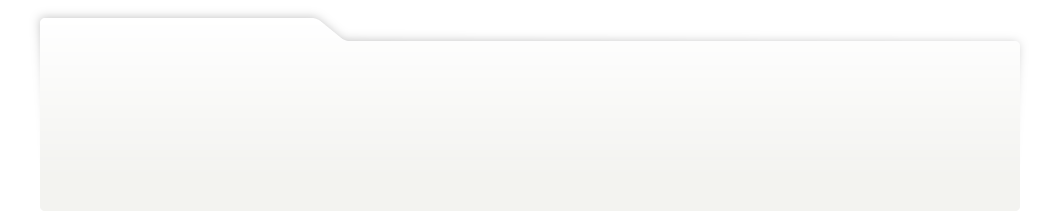
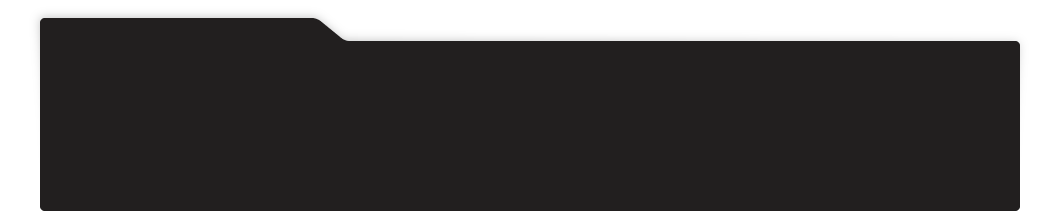
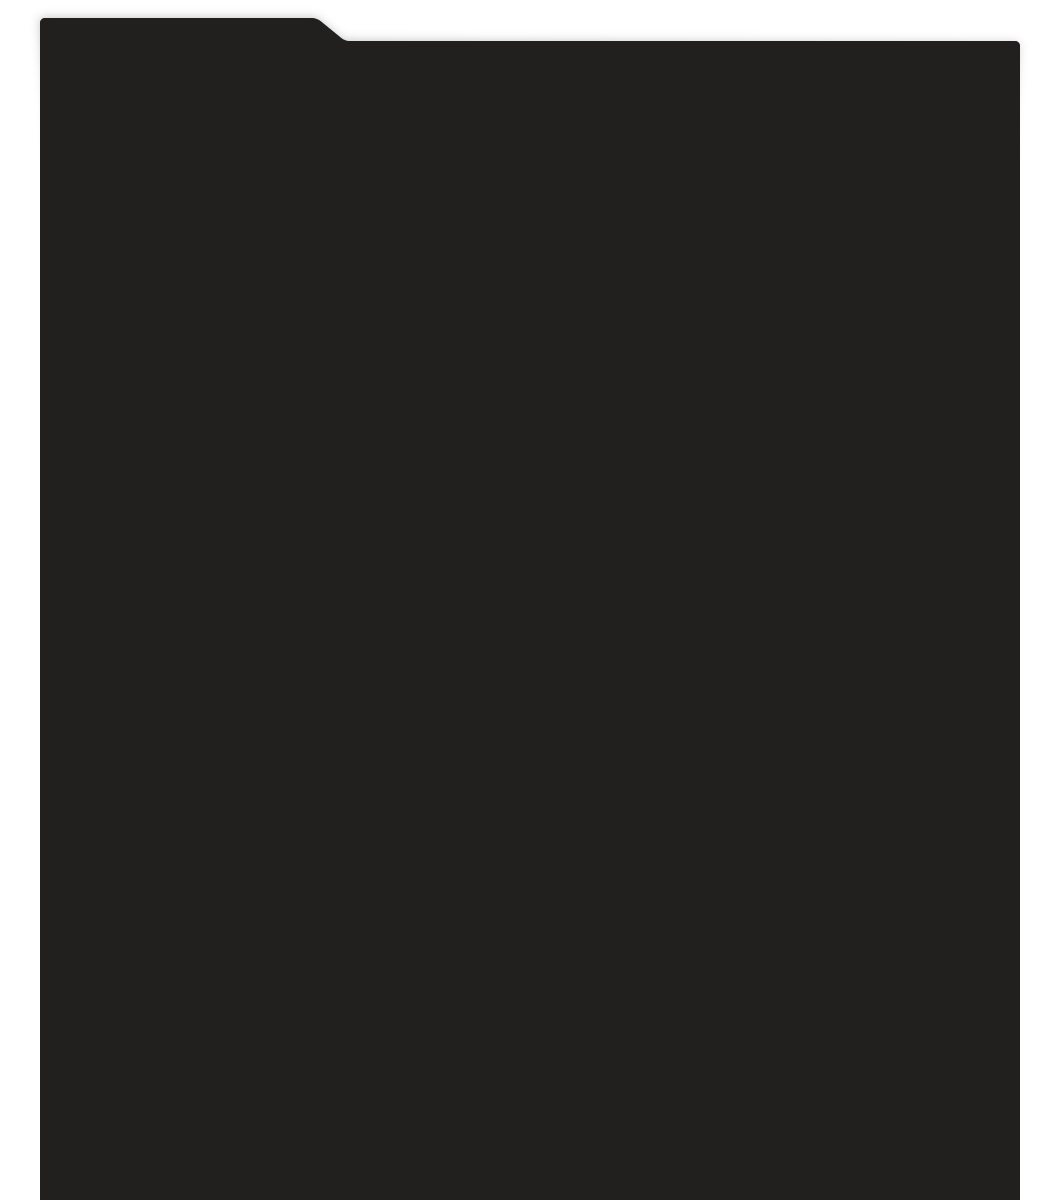
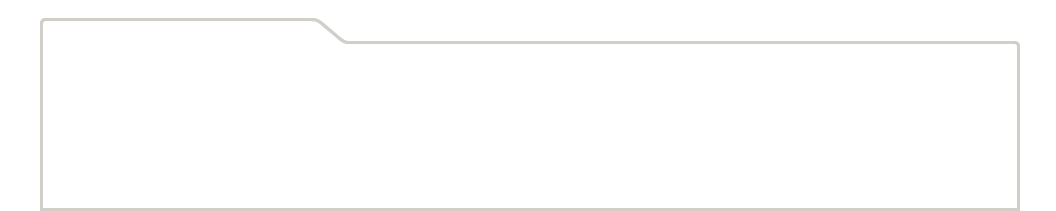
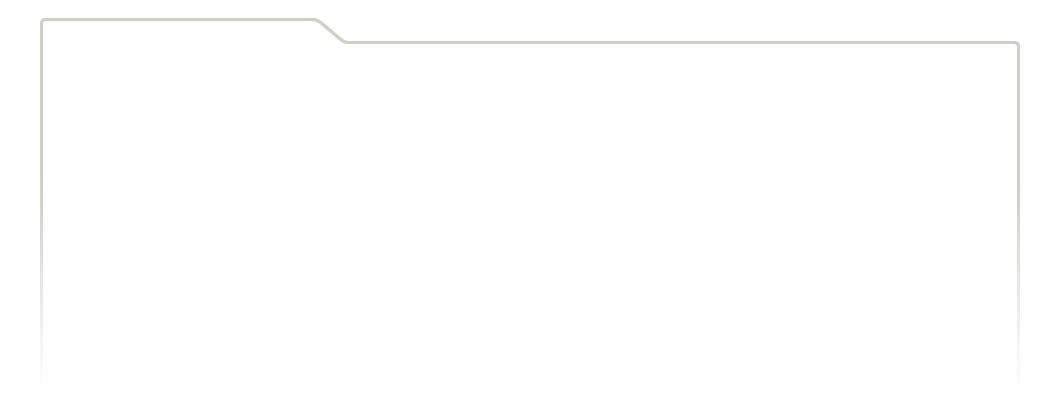
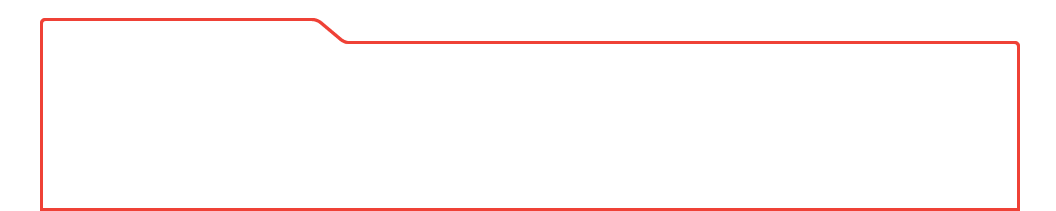
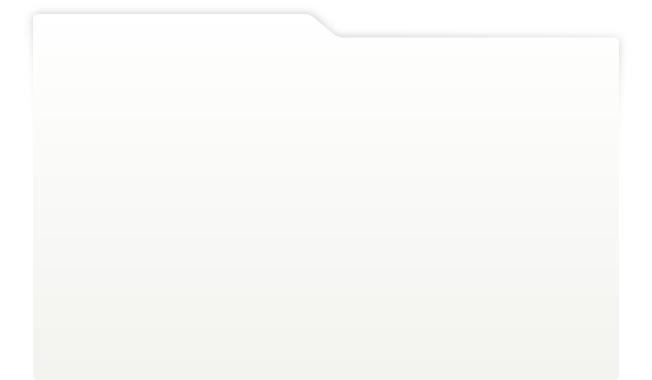
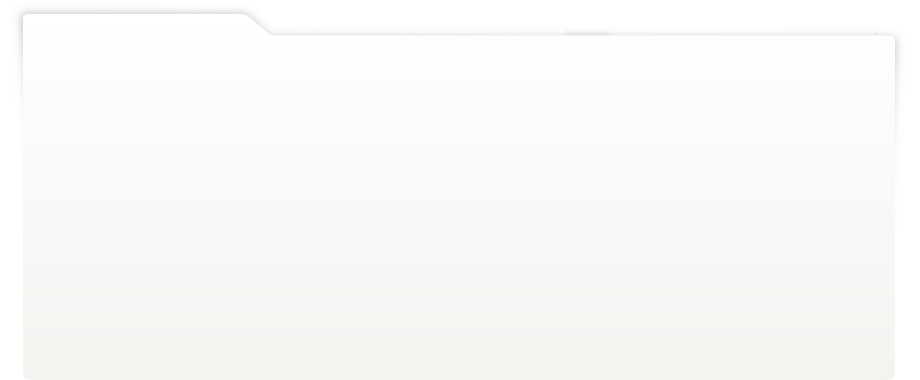
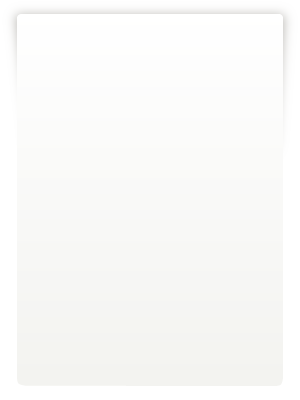
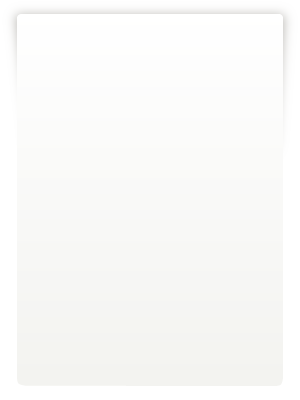
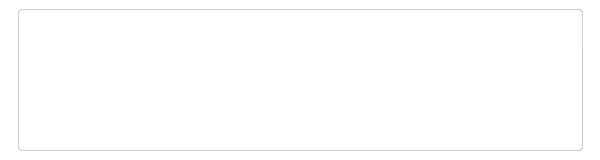
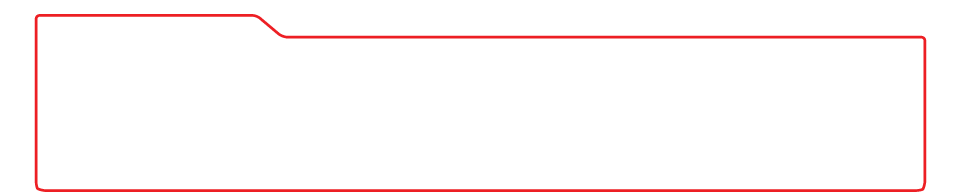
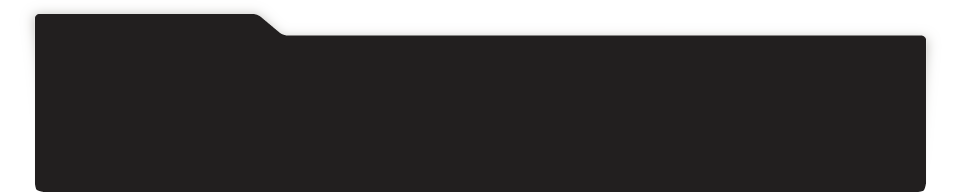
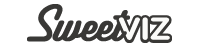
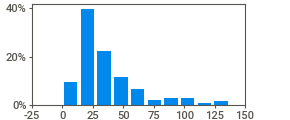
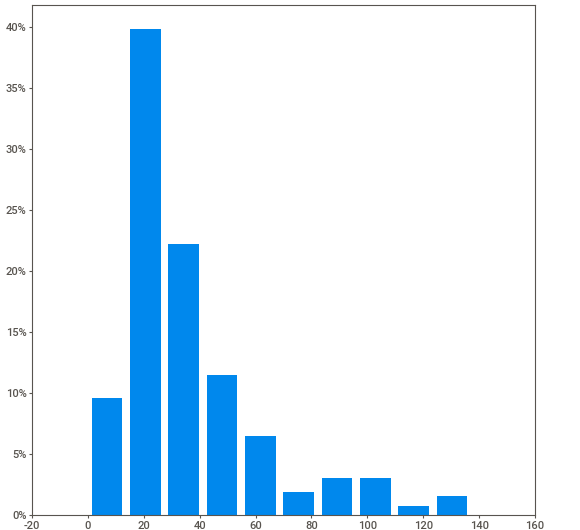
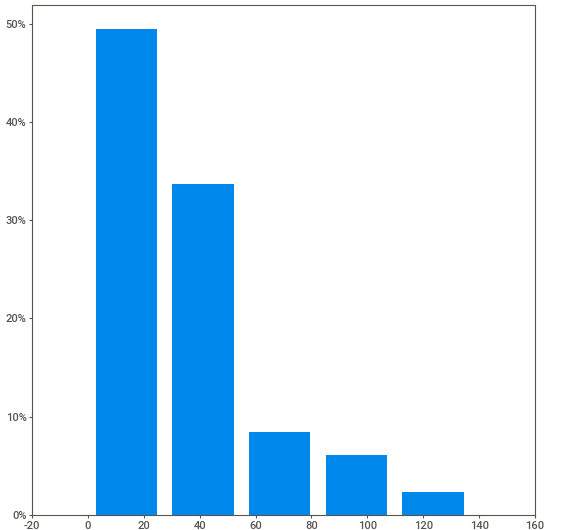
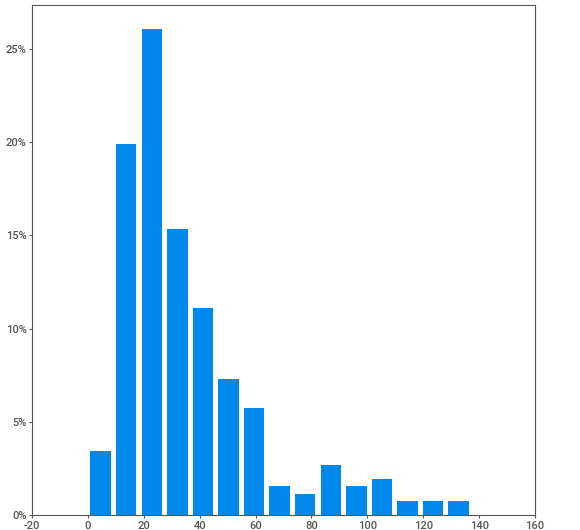
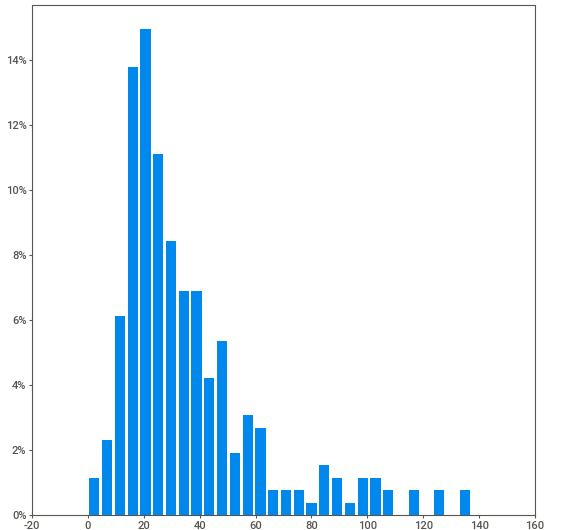
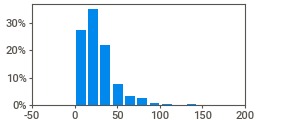
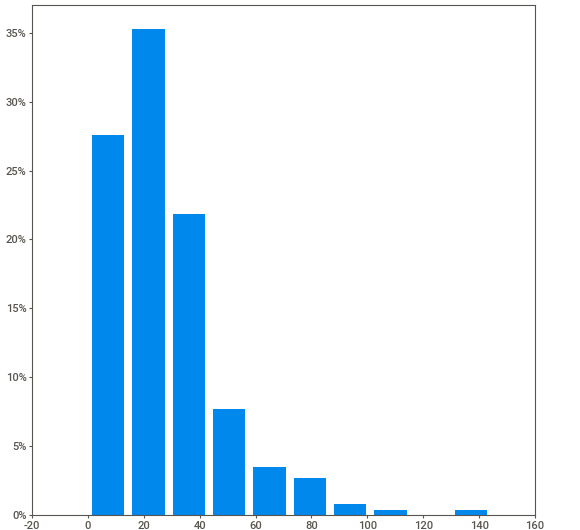
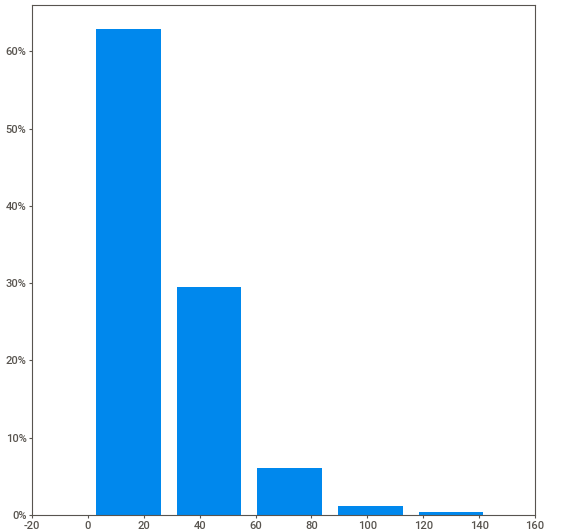
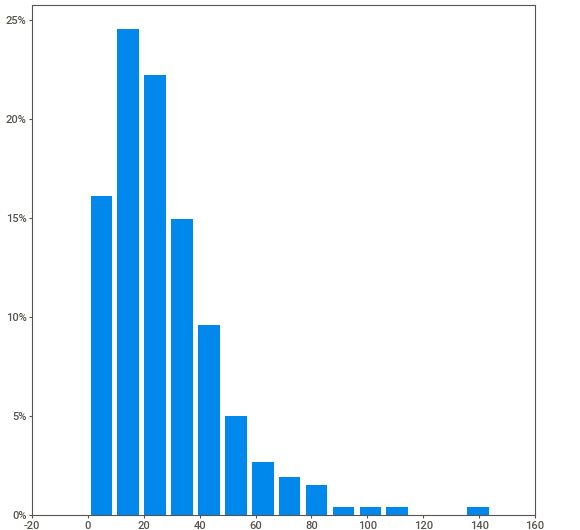
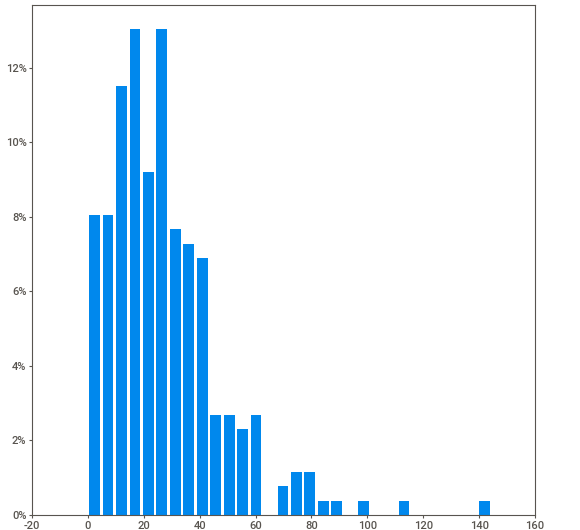
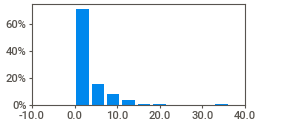
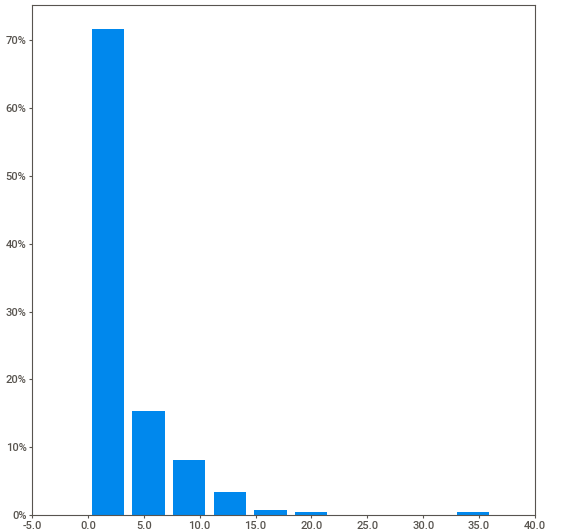
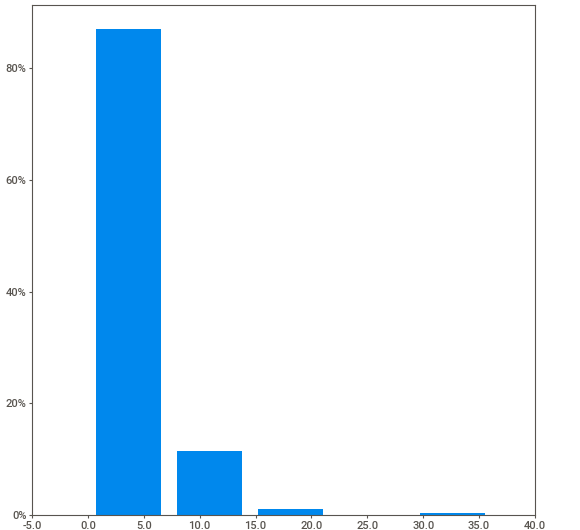
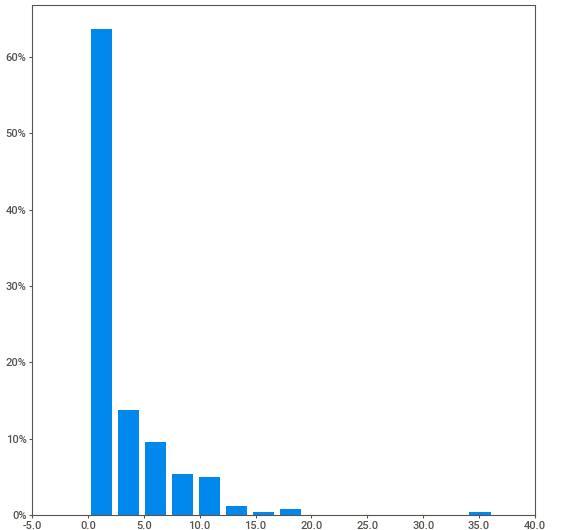
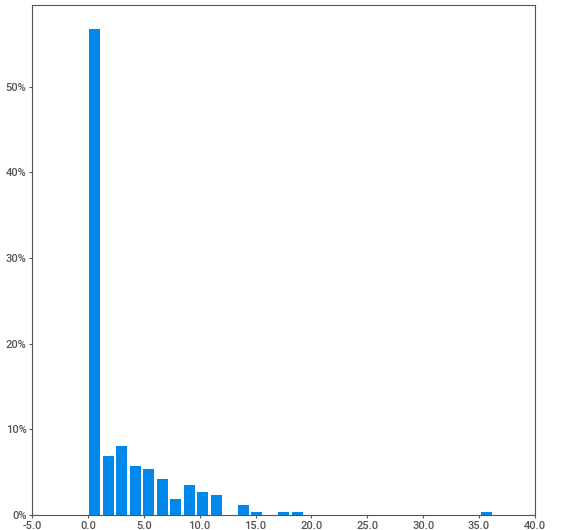
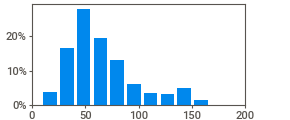
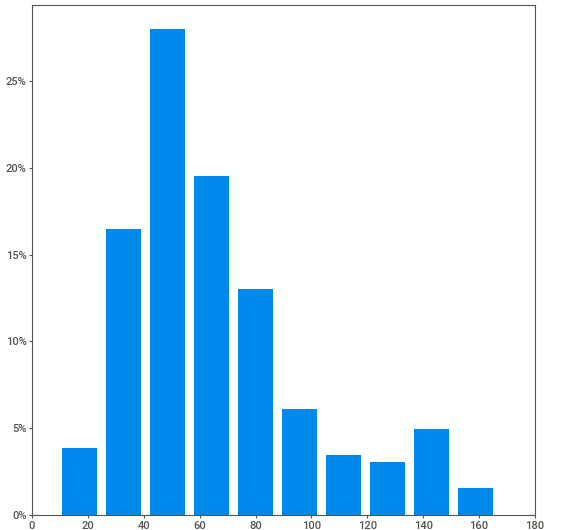
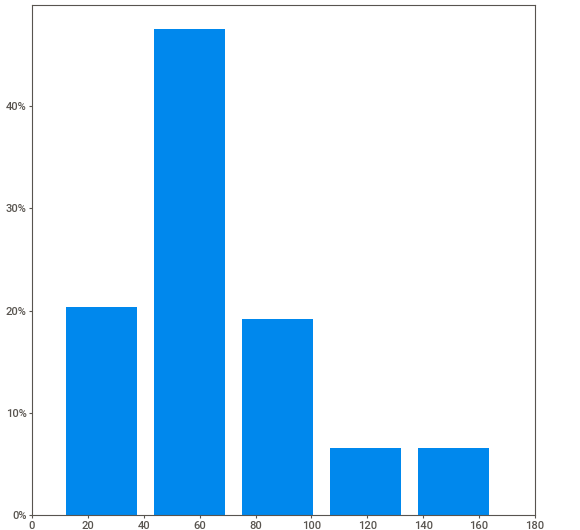
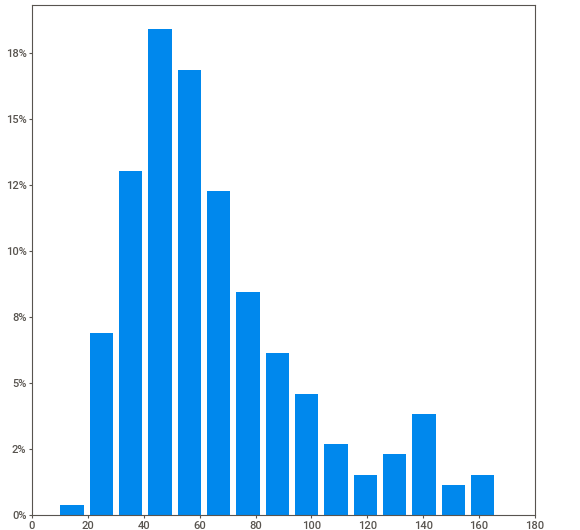
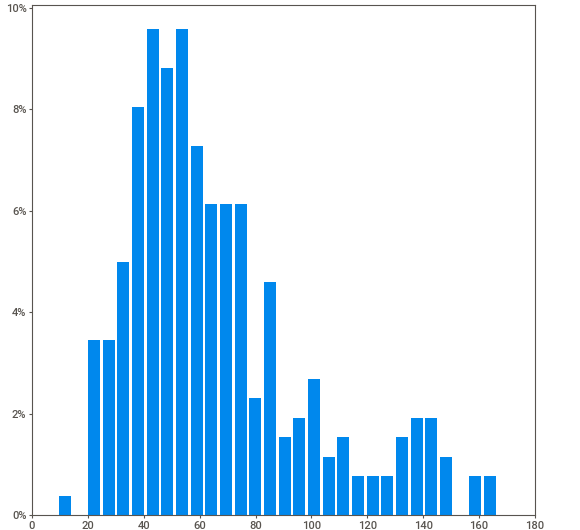
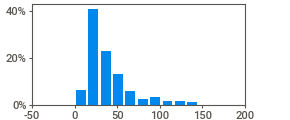
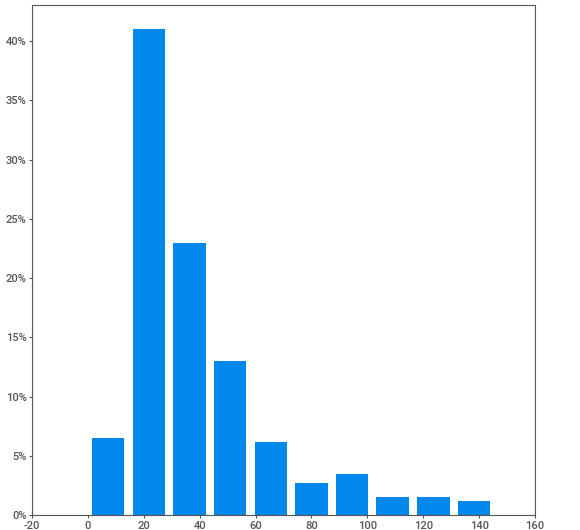
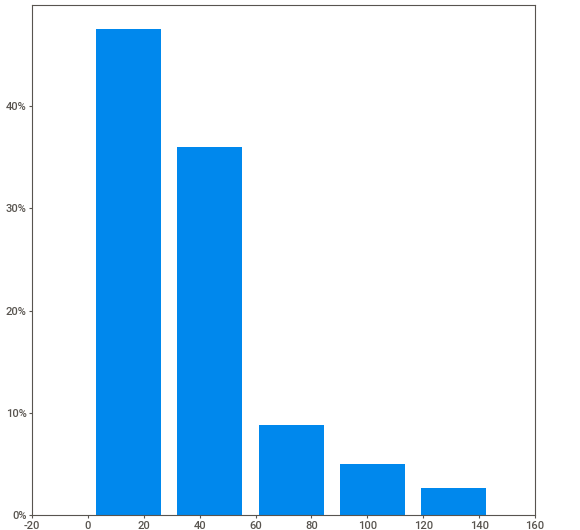
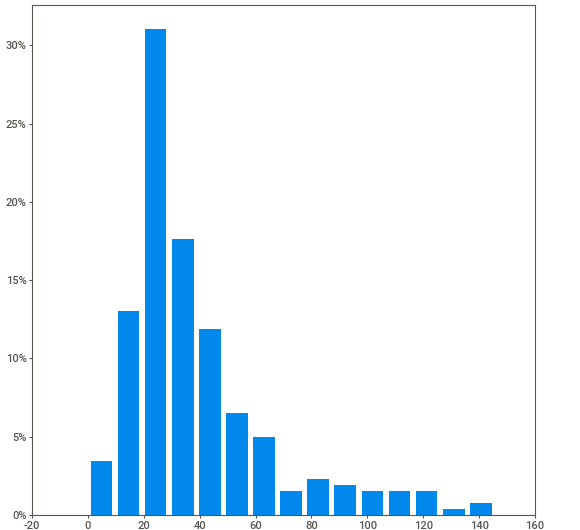
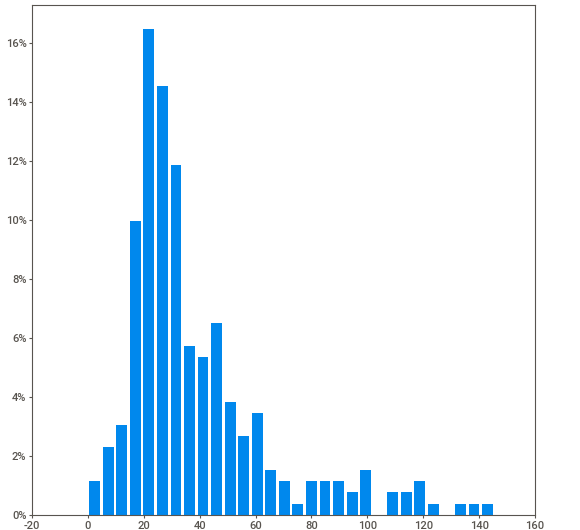
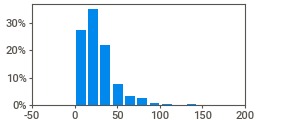
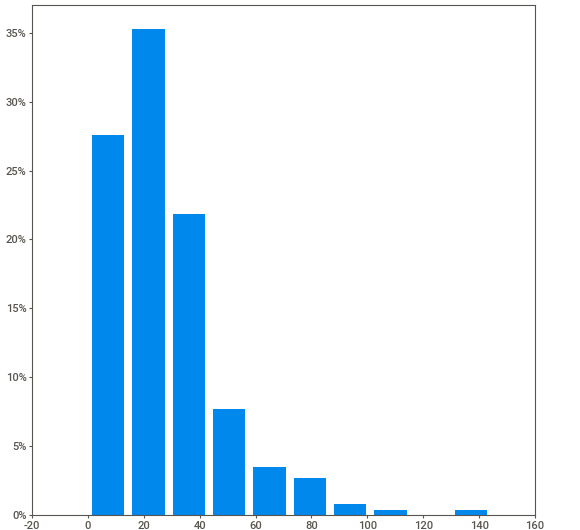
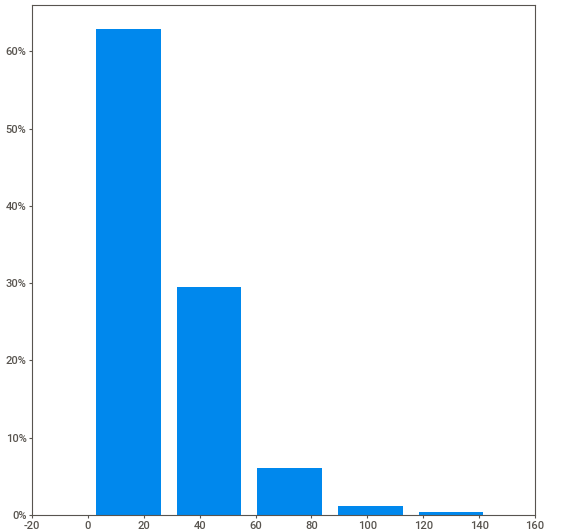
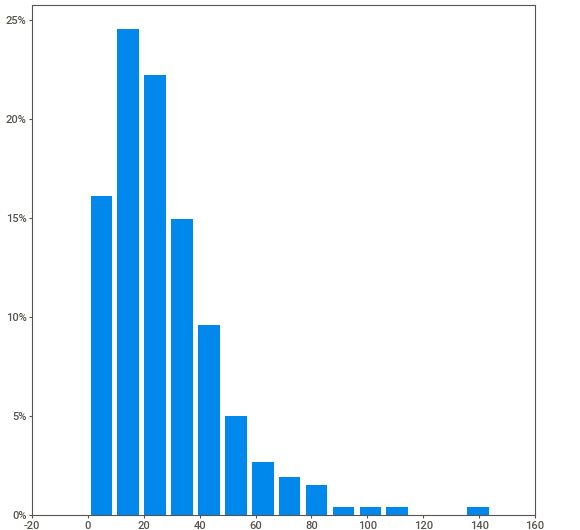
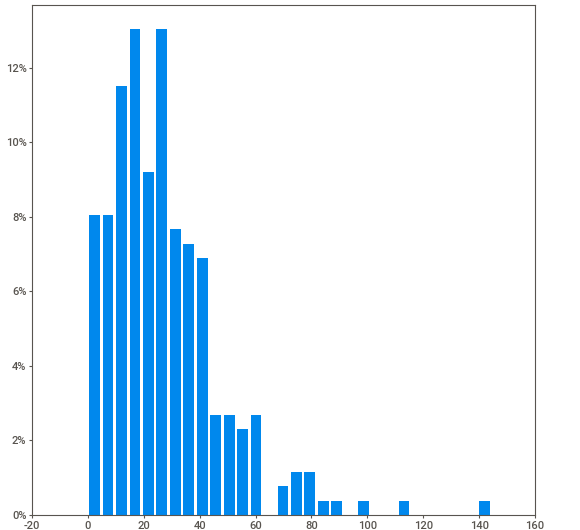
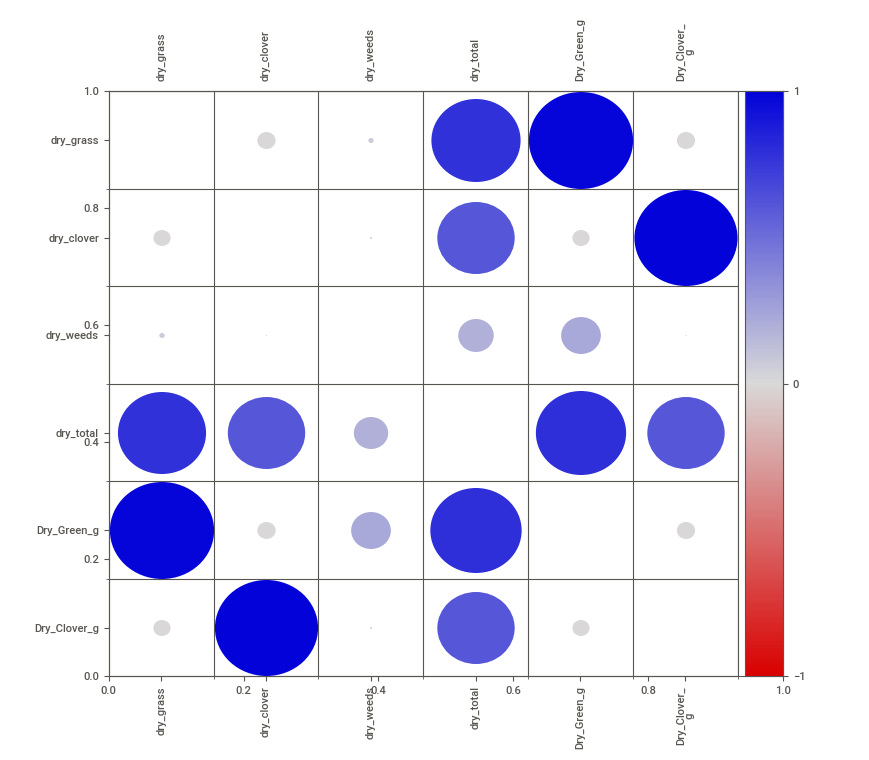
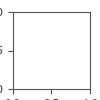

In [6]:
import sweetviz as sv
report = sv.analyze(
    df,
    feat_cfg=sv.FeatureConfig(skip=["image_file_name", "seasonal_harvest_no"])
)
report.show_notebook(w="100%", h="full")